In [13]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)


%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch

import pandas as pd
import numpy.matlib as matlib
import scipy
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO


from phaseEM import *
from extract_features import *
from channel_evaluation import *
from reconstruction_minimal import reconstruct
import config as cfg
from notebookfunctions import *


feat_path = r'./features'
result_path = r'./results'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
#try PLS (with PCA)
reconstruct(None, model = 'PLS', SSPEfeatures=True)

sub-01 has mean correlation of 0.538431
sub-02 has mean correlation of 0.562616
sub-03 has mean correlation of 0.743341
sub-04 has mean correlation of 0.765477
sub-05 has mean correlation of 0.520681
sub-06 has mean correlation of 0.828013
sub-07 has mean correlation of 0.730806
sub-08 has mean correlation of 0.611926
sub-09 has mean correlation of 0.683238
sub-10 has mean correlation of 0.652625


In [7]:
reconstruct(None,model = 'PLS', SSPEfeatures=False, saveAs = 'bandpass_PLS')

sub-01 has mean correlation of 0.591944
sub-02 has mean correlation of 0.626494
sub-03 has mean correlation of 0.828997
sub-04 has mean correlation of 0.785363
sub-05 has mean correlation of 0.557823
sub-06 has mean correlation of 0.862156
sub-07 has mean correlation of 0.746379
sub-08 has mean correlation of 0.703547
sub-09 has mean correlation of 0.691249
sub-10 has mean correlation of 0.673527


sub-01 has mean correlation of 0.520780
sub-02 has mean correlation of 0.593527
sub-03 has mean correlation of 0.752416
sub-04 has mean correlation of 0.775714
sub-05 has mean correlation of 0.523549
sub-06 has mean correlation of 0.801115
sub-07 has mean correlation of 0.723134
sub-08 has mean correlation of 0.592444
sub-09 has mean correlation of 0.608746
sub-10 has mean correlation of 0.619954
sub-01 has mean correlation of 0.585701
sub-02 has mean correlation of 0.649651
sub-03 has mean correlation of 0.844552
sub-04 has mean correlation of 0.793846
sub-05 has mean correlation of 0.576306
sub-06 has mean correlation of 0.869093
sub-07 has mean correlation of 0.709510
sub-08 has mean correlation of 0.716883
sub-09 has mean correlation of 0.668433
sub-10 has mean correlation of 0.704229
sub-01 has mean correlation of 0.549441
sub-02 has mean correlation of 0.583430
sub-03 has mean correlation of 0.767393
sub-04 has mean correlation of 0.776906
sub-05 has mean correlation of 0.537265


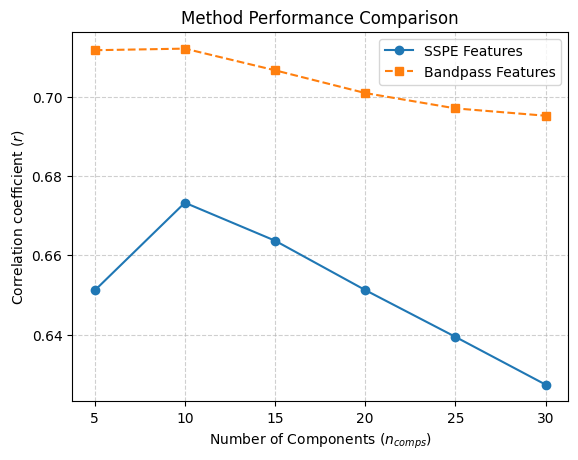

In [10]:
r_sppe = []
r_bandpass = []
n_comps_list = [5, 10, 15, 20, 25, 30]
for i, n in enumerate(n_comps_list):
    r_sppe.append(reconstruct(None, model = 'PLS', n_comp=n, SSPEfeatures=True, saveAs = 'dont'))
    r_bandpass.append(reconstruct(None, model = 'PLS', n_comp=n, SSPEfeatures=False, saveAs = 'dont'))

# Plotting Results
plt.plot(n_comps_list, [np.mean(val) for val in r_sppe], label='SSPE Features', marker='o', linestyle='-')
plt.plot(n_comps_list, [np.mean(val) for val in r_bandpass], label='Bandpass Features', marker='s', linestyle='--')

# Formatting with LaTeX notation
plt.xlabel(r'Number of Components ($n_{comps}$)')
plt.ylabel(r'Correlation coefficient ($r$)')
plt.title('Method Performance Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


In [ ]:
freqs = initParams_list[ch_idx]['freqs']

In [29]:

r_sppe = []
r_bandpass = []

for i in range(1,16):
    r_sppe.append(reconstruct(None, model = 'PLS', n_comp=i, SSPEfeatures=True, saveAs = 'dont'))
    r_bandpass.append(reconstruct(None, model = 'PLS', n_comp=i, SSPEfeatures=False, saveAs = 'dont'))

# Plotting Results
plt.plot(n_comps_list, [np.mean(val) for val in r_sppe], label='SSPE Features', marker='o', linestyle='-')
plt.plot(n_comps_list, [np.mean(val) for val in r_bandpass], label='Bandpass Features', marker='s', linestyle='--')

# Formatting with LaTeX notation
plt.xlabel(r'Number of Components ($n_{comps}$)')
plt.ylabel(r'Correlation coefficient ($r$)')
plt.title('Performance comparison for number of components in PLS')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)




sub-01 has mean correlation of 0.278716
sub-02 has mean correlation of 0.393264
sub-03 has mean correlation of 0.511073
sub-04 has mean correlation of 0.571334
sub-05 has mean correlation of 0.317257
sub-06 has mean correlation of 0.336599
sub-07 has mean correlation of 0.429360
sub-08 has mean correlation of 0.451308
sub-09 has mean correlation of 0.243604
sub-10 has mean correlation of 0.457570
sub-01 has mean correlation of 0.383461
sub-02 has mean correlation of 0.560944
sub-03 has mean correlation of 0.722987
sub-04 has mean correlation of 0.615082
sub-05 has mean correlation of 0.429315
sub-06 has mean correlation of 0.773503
sub-07 has mean correlation of 0.463252
sub-08 has mean correlation of 0.680421
sub-09 has mean correlation of 0.273792
sub-10 has mean correlation of 0.544120
sub-01 has mean correlation of 0.404570
sub-02 has mean correlation of 0.480909
sub-03 has mean correlation of 0.652646
sub-04 has mean correlation of 0.670584
sub-05 has mean correlation of 0.411084


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [42]:
#reconstruct(None, model = 'PLS', n_comp=9, SSPEfeatures=True, saveAs = 'SSPE_PLS')
reconstruct(None, model = 'PLS', n_comp=5, SSPEfeatures=False, saveAs = 'Bandpass_PLS')

sub-01 has mean correlation of 0.585701
sub-02 has mean correlation of 0.649651
sub-03 has mean correlation of 0.844552
sub-04 has mean correlation of 0.793846
sub-05 has mean correlation of 0.576306
sub-06 has mean correlation of 0.869093
sub-07 has mean correlation of 0.709510
sub-08 has mean correlation of 0.716883
sub-09 has mean correlation of 0.668433
sub-10 has mean correlation of 0.704229


(array([[[0.38494066, 0.4474256 , 0.54865657, ..., 0.45323589,
          0.44691918, 0.40017013],
         [0.6159538 , 0.65026658, 0.66720421, ..., 0.57452079,
          0.54927386, 0.50478388],
         [0.48688392, 0.51340658, 0.54079921, ..., 0.33714776,
          0.30026992, 0.25780743],
         ...,
         [0.47992982, 0.51309613, 0.54828444, ..., 0.47516282,
          0.46235633, 0.42872534],
         [0.61182286, 0.64935743, 0.68444041, ..., 0.54217724,
          0.52107539, 0.45935992],
         [0.62882525, 0.65606176, 0.67274057, ..., 0.50455662,
          0.48911227, 0.43205199]],
 
        [[0.65667237, 0.65814342, 0.66943005, ..., 0.65402297,
          0.63322514, 0.55574625],
         [0.64693122, 0.660475  , 0.67189062, ..., 0.59495606,
          0.56797499, 0.48847164],
         [0.63316937, 0.65906015, 0.66100882, ..., 0.6020801 ,
          0.58091822, 0.52690385],
         ...,
         [0.71748089, 0.71942359, 0.7353605 , ..., 0.65519889,
          0.61407527, 0.

0.6846


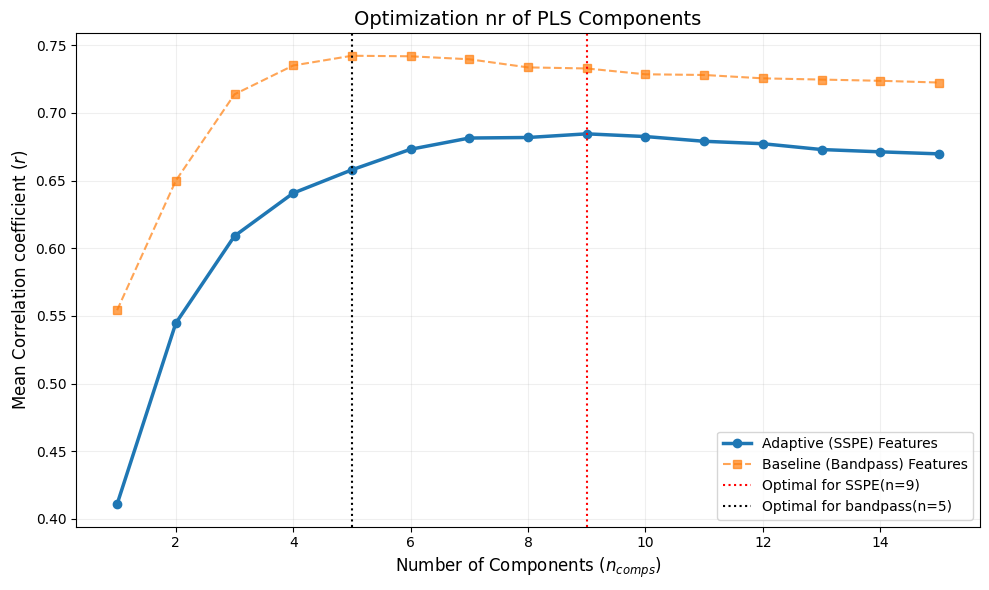

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Raw Data Input (Extracted from your logs)
raw_data = [
    0.278716, 0.393264, 0.511073, 0.571334, 0.317257, 0.336599, 0.429360, 0.451308, 0.243604, 0.457570, # n=1 SSPE
    0.383461, 0.560944, 0.722987, 0.615082, 0.429315, 0.773503, 0.463252, 0.680421, 0.273792, 0.544120, # n=1 BP
    0.404570, 0.480909, 0.652646, 0.670584, 0.411084, 0.707795, 0.628390, 0.585415, 0.413108, 0.492016, # n=2 SSPE
    0.488441, 0.610807, 0.796186, 0.755545, 0.512079, 0.852174, 0.613257, 0.700362, 0.455714, 0.612138, # n=2 BP
    0.450636, 0.546746, 0.710191, 0.715544, 0.442933, 0.773243, 0.690367, 0.573119, 0.533545, 0.550861, # n=3 SSPE
    0.550954, 0.630765, 0.836686, 0.781300, 0.545463, 0.861882, 0.675692, 0.710910, 0.622647, 0.694452, # n=3 BP
    0.497362, 0.564652, 0.731244, 0.750419, 0.502280, 0.786704, 0.700430, 0.584473, 0.590284, 0.598311, # n=4 SSPE
    0.564859, 0.646446, 0.841922, 0.785861, 0.569378, 0.866255, 0.700773, 0.716723, 0.653418, 0.702160, # n=4 BP
    0.520780, 0.593527, 0.752416, 0.775714, 0.523549, 0.801115, 0.723134, 0.592444, 0.608746, 0.619954, # n=5 SSPE
    0.585701, 0.649651, 0.844552, 0.793846, 0.576306, 0.869093, 0.709510, 0.716883, 0.668433, 0.704229, # n=5 BP
    0.539350, 0.597928, 0.764781, 0.782141, 0.523622, 0.811373, 0.739862, 0.605515, 0.640300, 0.641628, # n=6 SSPE
    0.593615, 0.647751, 0.842814, 0.794639, 0.573370, 0.868753, 0.728290, 0.715410, 0.683389, 0.703290, # n=6 BP
    0.545577, 0.594753, 0.772392, 0.788242, 0.535259, 0.817606, 0.749891, 0.611714, 0.660078, 0.649998, # n=7 SSPE
    0.596353, 0.644572, 0.839863, 0.792326, 0.573993, 0.867384, 0.734068, 0.712281, 0.689264, 0.699081, # n=7 BP
    0.547407, 0.595329, 0.771673, 0.784176, 0.534302, 0.819349, 0.747860, 0.613054, 0.671664, 0.652315, # n=8 SSPE
    0.597697, 0.641499, 0.836140, 0.791508, 0.568963, 0.867437, 0.745855, 0.709842, 0.691304, 0.692883, # n=8 BP
    0.548866, 0.590674, 0.771208, 0.779386, 0.536557, 0.824812, 0.750376, 0.608173, 0.673381, 0.662176, # n=9 SSPE
    0.596009, 0.640852, 0.834589, 0.790965, 0.566431, 0.866457, 0.747233, 0.708892, 0.697047, 0.689011, # n=9 BP
    0.549441, 0.583430, 0.767393, 0.776906, 0.537265, 0.826168, 0.747097, 0.610063, 0.675638, 0.659678, # n=10 SSPE
    0.595543, 0.636524, 0.833814, 0.791562, 0.561394, 0.865485, 0.746718, 0.708016, 0.696914, 0.686272, # n=10 BP
    0.549798, 0.579193, 0.762948, 0.775994, 0.546417, 0.828126, 0.743149, 0.610767, 0.678783, 0.652477, # n=11 SSPE
    0.595948, 0.635219, 0.832362, 0.791836, 0.560094, 0.864751, 0.746726, 0.707446, 0.696962, 0.685773, # n=11 BP
    0.548615, 0.572875, 0.757621, 0.772025, 0.537383, 0.829973, 0.739586, 0.614543, 0.681326, 0.656672, # n=12 SSPE
    0.597287, 0.633989, 0.831010, 0.788237, 0.559771, 0.863738, 0.746898, 0.705882, 0.697445, 0.682337, # n=12 BP
    0.544326, 0.563889, 0.752950, 0.771870, 0.531685, 0.830324, 0.737575, 0.615128, 0.684286, 0.648832, # n=13 SSPE
    0.596178, 0.632022, 0.830146, 0.786977, 0.559027, 0.862926, 0.746770, 0.704804, 0.696518, 0.679136, # n=13 BP
    0.541133, 0.565066, 0.747565, 0.767758, 0.529605, 0.828915, 0.734720, 0.613411, 0.683537, 0.649444, # n=14 SSPE
    0.594080, 0.630240, 0.829192, 0.786195, 0.557829, 0.862377, 0.746050, 0.704132, 0.694318, 0.675697, # n=14 BP
    0.538431, 0.562616, 0.743341, 0.765477, 0.520681, 0.828013, 0.730806, 0.611926, 0.683238, 0.652625, # n=15 SSPE
    0.591944, 0.626494, 0.828997, 0.785363, 0.557823, 0.862156, 0.746379, 0.703547, 0.691249, 0.673527  # n=15 BP
]
sspe_means = np.array([
    0.4110, # n=1
    0.5447, # n=2
    0.6091, # n=3
    0.6408, # n=4
    0.6580, # n=5
    0.6732, # n=6
    0.6815, # n=7
    0.6819, # n=8
    0.6846, # n=9
    0.6826, # n=10
    0.6791, # n=11
    0.6773, # n=12
    0.6730, # n=13
    0.6713, # n=14
    0.6698  # n=15
])

bp_means = np.array([
    0.5543, # n=1
    0.6500, # n=2
    0.7138, # n=3
    0.7351, # n=4
    0.7423, # n=5
    0.7419, # n=6
    0.7397, # n=7
    0.7337, # n=8
    0.7329, # n=9
    0.7286, # n=10
    0.7281, # n=11
    0.7256, # n=12
    0.7247, # n=13
    0.7238, # n=14
    0.7225  # n=15
])
n_comps = np.arange(1, 16)
print(np.max(sspe_means))
plt.figure(figsize=(10, 6))

plt.plot(n_comps, sspe_means, label='Adaptive (SSPE) Features', marker='o', linewidth=2.5)
plt.plot(n_comps, bp_means, label='Baseline (Bandpass) Features', linestyle='--', marker='s', alpha=0.7)

# Highlight the optimal choice
plt.axvline(9, color='red', linestyle=':', label='Optimal for SSPE(n=9)')
plt.axvline(5, color='black', linestyle=':', label='Optimal for bandpass(n=5)')

plt.title('Optimization nr of PLS Components', fontsize=14)
plt.xlabel('Number of Components ($n_{comps}$)', fontsize=12)
plt.ylabel('Mean Correlation coefficient ($r$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

nr of frequencies in somata results in total: 478
Original Osc Count: 534
Expected Stacked Features: 4806
Actual Model Feature Count: 4806


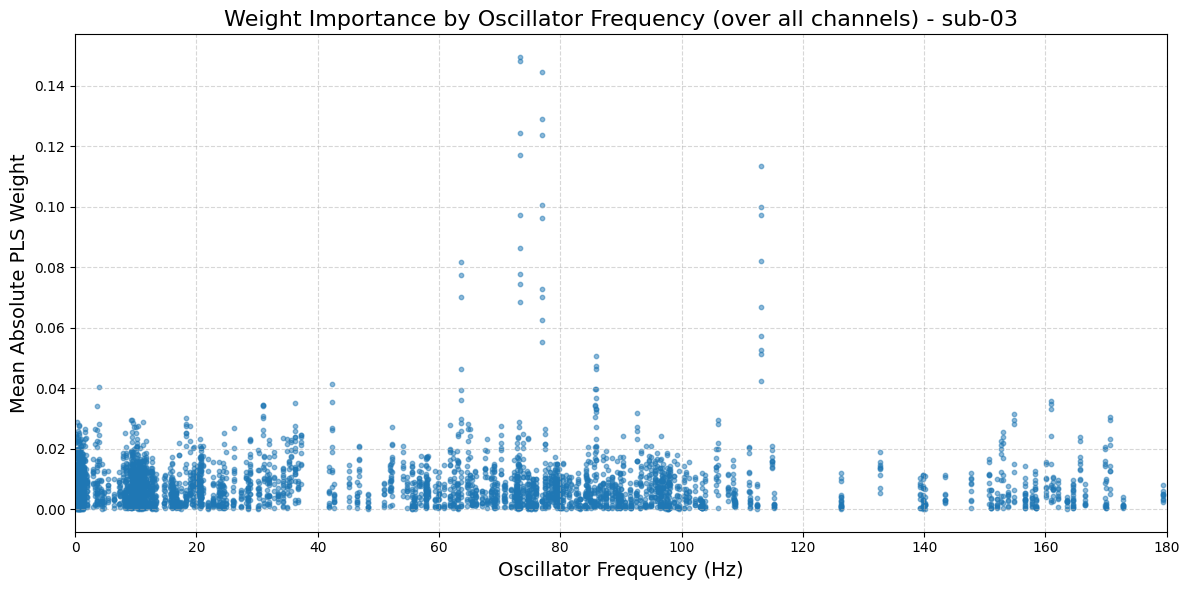

In [24]:
pt = 'sub-03'

r, weights = reconstruct([pt], model = 'PLS', n_comp=10, SSPEfeatures=True, saveAs = 'dont')
importance = np.mean(np.abs(weights), axis=1)

freqs = get_initParams(pt) 

plt.figure(figsize=(12, 6))
plt.bar(freqs, importance, width=1.5, color='teal', alpha=0.7)

plt.title('PLS Oscillator Importance by Frequency (Sub-03)', fontsize=16)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Mean Absolute PLS Weight', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


initParams_list = get_initParams(pt)
all_osc_freqs = []
for ch_params in initParams_list:
    all_osc_freqs.extend(ch_params['freqs'])

all_osc_freqs = np.array(all_osc_freqs)
all_stacked_freqs = np.tile(all_osc_freqs, 9)

importance = np.mean(np.abs(weights), axis=0)

print(f"Original Osc Count: {len(all_osc_freqs)}")
print(f"Expected Stacked Features: {len(all_osc_freqs) * 9}")
print(f"Actual Model Feature Count: {len(importance)}")
plt.figure(figsize=(12, 6))

plt.scatter(all_stacked_freqs, importance, alpha=0.5, s=10)

plt.title('Weight Importance by Oscillator Frequency (over all channels) - sub-03', fontsize=16)
plt.xlabel('Oscillator Frequency (Hz)', fontsize=14)
plt.ylabel('Mean Absolute PLS Weight', fontsize=14)
plt.xlim([0, 180]) # Focus on your range of interest
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

nr of frequencies in somata results in total: 307
Original Osc Count: 759
Expected Stacked Features: 6831
Actual Model Feature Count: 6831


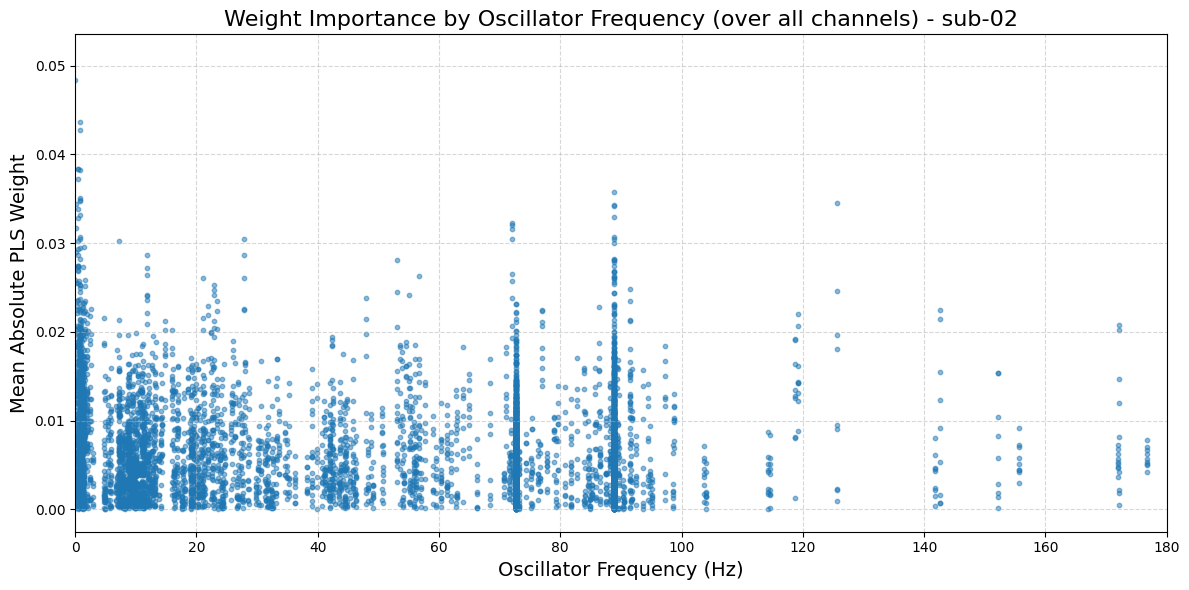

In [26]:
pt = 'sub-02'

r, weights = reconstruct([pt], model = 'PLS', n_comp=10, SSPEfeatures=True, saveAs = 'dont')

initParams_list = get_initParams(pt)
all_osc_freqs = []
for ch_params in initParams_list:
    all_osc_freqs.extend(ch_params['freqs'])

all_osc_freqs = np.array(all_osc_freqs)
all_stacked_freqs = np.tile(all_osc_freqs, 9)

importance = np.mean(np.abs(weights), axis=0)

print(f"Original Osc Count: {len(all_osc_freqs)}")
print(f"Expected Stacked Features: {len(all_osc_freqs) * 9}")
print(f"Actual Model Feature Count: {len(importance)}")
# 3. Create the bar chart
plt.figure(figsize=(12, 6))


plt.scatter(all_stacked_freqs, importance, alpha=0.5, s=10)

plt.title('Weight Importance by Oscillator Frequency (over all channels) - sub-02', fontsize=16)
plt.xlabel('Oscillator Frequency (Hz)', fontsize=14)
plt.ylabel('Mean Absolute PLS Weight', fontsize=14)
plt.xlim([0, 180]) # Focus on your range of interest
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()